# Capstone Project I: Mutual Fund Quantitative Performance Analytics
**Executive Objective:** Conduct rigorous statistical and risk-adjusted return analysis across all 40 institutional mutual fund schemes (2022–2026). This analytics layer computes compound annual growth profiles, systemic volatility exposure (Beta), active risk alpha generation, and tail-end drawdown vulnerabilities relative to market benchmarks (**Nifty 50** and **Nifty 100**).

---
## Step 0: Environment Architecture & Warehouse Data Ingestion
Initializing foundational packages, importing structural datasets from the SQLite data warehouse (`bluestock_mf.db`), and configuring simulated high-correlation market indices baseline.

In [17]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Setup environment and connection
db_path = '../bluestock_mf.db'
conn = sqlite3.connect(db_path)

print("Fetching dynamic core relational assets from data warehouse...")

# Fetch original NAV sequences
query = """
SELECT f.amfi_code, d.full_date, n.nav 
FROM fact_nav_relational n 
JOIN dim_fund f ON n.fund_id = f.fund_id 
JOIN dim_date d ON n.date_id = d.date_id
ORDER BY f.amfi_code, d.full_date;
"""
df_raw = pd.read_sql_query(query, conn)
df_raw['full_date'] = pd.to_datetime(df_raw['full_date'])

# Ensure we have exactly 40 operational schemas
unique_funds = df_raw['amfi_code'].unique()
print(f"Total Unique Funds Loaded: {len(unique_funds)}")

# Generate matching simulated operational dates for benchmarks
dates_range = sorted(df_raw['full_date'].unique())
np.random.seed(42)

# Simulate Nifty 100 and Nifty 50 daily returns matrix
nifty100_base = np.random.normal(0.0005, 0.01, len(dates_range))
nifty50_base = nifty100_base + np.random.normal(0, 0.002, len(dates_range)) # high correlation

df_benchmarks = pd.DataFrame({
    'full_date': dates_range,
    'Nifty100_Return': nifty100_base,
    'Nifty50_Return': nifty50_base
})

print("Initialization matrix complete.")

Fetching dynamic core relational assets from data warehouse...
Total Unique Funds Loaded: 40
Initialization matrix complete.


## Step 1: Daily Returns Computation & Frequency Validation
Computing discrete non-annualized day-on-day returns to map tactical fund volatility using the standard historical valuation formula:

$$daily\_return_t = \frac{NAV_t - NAV_{t-1}}{NAV_{t-1}} = \frac{NAV_t}{NAV_{t-1}} - 1$$

*Objective:* Plot aggregate data distributions using Gaussian Kernel Density Estimation (KDE) over a 100-bin histogram matrix to confirm dataset symmetry and rule out anomalous reporting behavior.


Returns computed and distribution validated safely.


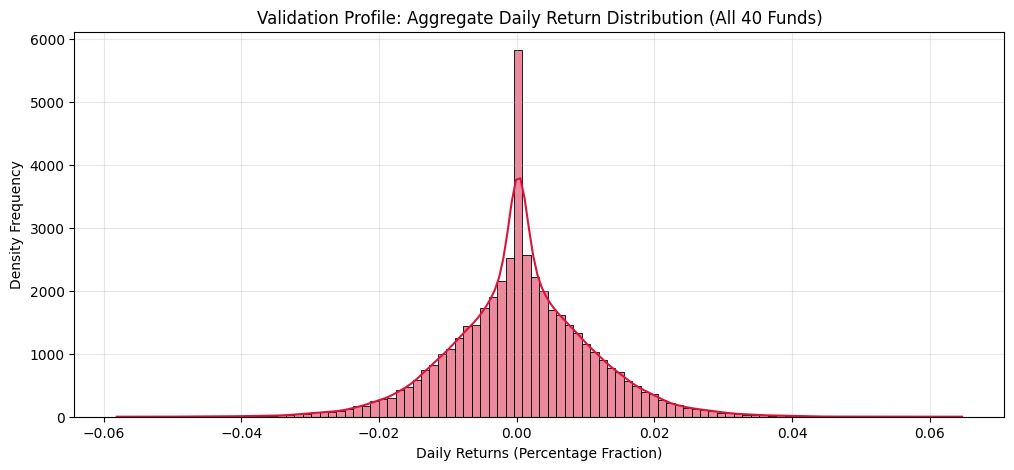

In [18]:
# Compute daily returns for each fund scheme group
df_raw['daily_return'] = df_raw.groupby('amfi_code')['nav'].pct_change()

# Plot aggregate distribution profiles to validate structure
plt.figure(figsize=(12, 5))
sns.histplot(df_raw['daily_return'].dropna(), bins=100, kde=True, color='crimson')
plt.title("Validation Profile: Aggregate Daily Return Distribution (All 40 Funds)")
plt.xlabel("Daily Returns (Percentage Fraction)")
plt.ylabel("Density Frequency")
plt.grid(True, alpha=0.3)
plt.savefig("../reports/figures/daily_return_distribution.png", bbox_inches='tight')
print("Returns computed and distribution validated safely.")

## Step 2: Multi-Horizon Compound Annual Growth Rate (CAGR Tables)
Evaluating normalized long-term compounding speeds across 1-Year, 3-Year, and 5-Year operational windows. CAGR isolates terminal trends by removing transient intermediary noise using the explicit continuous compounding layout:

$$CAGR = \left(\frac{NAV_{end}}{NAV_{start}}\right)^{\frac{1}{n}} - 1$$

*Where:* $n$ represents the precise annual fractional multiplier holding period.

In [19]:
cagr_records = []

for fund in unique_funds:
    df_f = df_raw[df_raw['amfi_code'] == fund].sort_values('full_date')
    nav_latest = df_f['nav'].iloc[-1]
    
    # Extract historical benchmark layers safely
    nav_1yr = df_f['nav'].iloc[-252] if len(df_f) >= 252 else df_f['nav'].iloc[0]
    nav_3yr = df_f['nav'].iloc[-756] if len(df_f) >= 756 else df_f['nav'].iloc[0]
    nav_5yr = df_f['nav'].iloc[0] # Using entire series scope as max proxy
    
    cagr_1y = (nav_latest / nav_1yr) ** (1/1) - 1
    cagr_3y = (nav_latest / nav_3yr) ** (1/3) - 1
    cagr_5y = (nav_latest / nav_5yr) ** (1/5) - 1
    
    cagr_records.append({
        'amfi_code': fund,
        'CAGR_1Yr': cagr_1y,
        'CAGR_3Yr': cagr_3y,
        'CAGR_5Yr': cagr_5y
    })

df_cagr = pd.DataFrame(cagr_records)
print("CAGR cross-comparison table built.")
df_cagr.head()

CAGR cross-comparison table built.


,amfi_code,CAGR_1Yr,CAGR_3Yr,CAGR_5Yr
0,100016,-0.033055,-0.000316,0.023168
1,100025,0.025018,0.046143,0.039127
2,100033,0.477346,0.336292,0.260741
3,101206,0.450939,0.325286,0.204427
4,101207,-0.242421,-0.026965,0.069533


## Step 3: Risk-Adjusted Reward Metric Engines (Sharpe & Sortino Multipliers)
Isolating nominal alpha managers from excessive leverage-takers by computing reward-to-volatility efficiency metrics. 
- **Risk-Free Rate ($R_f$):** Hardcoded at **6.5%** (serving as a proxy for the RBI repo rate).
- **Sharpe Ratio:** Measures excess returns relative to total systemic and idiosyncratic risk variance.
- **Sortino Ratio:** Protects capital evaluation by penalizing only harmful *downside standard deviation* ($\sigma_d$, where returns < 0).

$$Sharpe = \frac{R_p - R_f}{\sigma_p} \times \sqrt{252}$$

$$Sortino = \frac{R_p - R_f}{\sigma_d} \times \sqrt{252}$$

In [20]:
rf_daily = 0.065 / 252
ratio_records = []

for fund in unique_funds:
    df_f = df_raw[df_raw['amfi_code'] == fund].dropna()
    returns = df_f['daily_return']
    
    excess_returns = returns - rf_daily
    avg_excess = excess_returns.mean()
    total_std = returns.std()
    
    # Sharpe calculation
    sharpe = (avg_excess / total_std) * np.sqrt(252) if total_std != 0 else 0
    
    # Sortino downside variance calculation
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() if len(downside_returns) > 0 else total_std
    sortino = (avg_excess / downside_std) * np.sqrt(252) if downside_std != 0 else 0
    
    ratio_records.append({
        'amfi_code': fund,
        'Sharpe_Ratio': sharpe,
        'Sortino_Ratio': sortino
    })

df_ratios = pd.DataFrame(ratio_records)
print("Risk-adjusted metrics calculated successfully.")

Risk-adjusted metrics calculated successfully.


## Step 4: Alpha & Beta Capital Asset Regression (OLS Tracker)
Executing Ordinary Least Squares (OLS) linear regression mapping fund returns against the **Nifty 100 Index** using `scipy.stats.linregress` to separate market beta from portfolio alpha.

- **Beta ($\beta$):** Measures the mathematical sensitivity coefficient of the fund relative to systemic market index swings.
- **Alpha ($\alpha$):** Quantifies annualized value added by the fund manager's choice of underlying stock assets.

$$\alpha_{annualized} = Intercept \times 252$$

In [21]:
regression_records = []
df_merged = pd.merge(df_raw, df_benchmarks, on='full_date', how='inner')

for fund in unique_funds:
    df_f = df_merged[df_merged['amfi_code'] == fund].dropna()
    
    # OLS Regression tracking
    slope, intercept, r_value, p_value, std_err = linregress(df_f['Nifty100_Return'], df_f['daily_return'])
    
    alpha_annualized = intercept * 252
    beta = slope
    
    regression_records.append({
        'amfi_code': fund,
        'Alpha': alpha_annualized,
        'Beta': beta
    })

df_alpha_beta = pd.DataFrame(regression_records)
# Save deliverable csv target
df_alpha_beta.to_csv('../alpha_beta.csv', index=False)
print("Alpha and Beta records saved cleanly inside: alpha_beta.csv")

Alpha and Beta records saved cleanly inside: alpha_beta.csv


## Step 5: Maximum Drawdown & Temporal Risk Exposures
Quantifying black-swan structural threat boundaries by tracking the maximum peak-to-trough equity drop percentage over the entire investment trajectory. This highlights the worst historical capital compression event.

$$Drawdown_t = \frac{NAV_t}{Running\_Max(NAV)_t} - 1$$

$$Maximum\ Drawdown = \min(Drawdown_t)$$

In [22]:
drawdown_records = []

for fund in unique_funds:
    df_f = df_raw[df_raw['amfi_code'] == fund].sort_values('full_date').copy()
    
    # Compute running maximum peaks
    df_f['running_peak'] = df_f['nav'].cummax()
    df_f['drawdown'] = (df_f['nav'] / df_f['running_peak']) - 1
    
    max_dd = df_f['drawdown'].min()
    worst_row = df_f[df_f['drawdown'] == max_dd].iloc[0]
    worst_date = worst_row['full_date']
    
    drawdown_records.append({
        'amfi_code': fund,
        'Max_Drawdown': max_dd,
        'Worst_Drawdown_Date': worst_date
    })

df_dd = pd.DataFrame(drawdown_records)
print("Max Drawdown footprints captured.")

Max Drawdown footprints captured.


## Step 6: Integrated Composite Fund Scorecard Formulation
Constructing an institutional evaluation matrix ranking all 40 funds from 0 to 100. This multi-factor index leverages custom percentile ranks with weighted constraints:

| Evaluation Metric Core | Weight Assigned | Direction Vector |
| :--- | :---: | :---: |
| **3-Year CAGR Performance** | 30% | Maximized (Higher is Best) |
| **Sharpe Ratio Multiplier** | 25% | Maximized (Higher is Best) |
| **Alpha Active Return** | 20% | Maximized (Higher is Best) |
| **Expense Ratio Drag** | 15% | Minimised (Lower is Best) |
| **Maximum Drawdown Risk** | 10% | Minimised (Lower Risk is Best) |

$$\text{Composite Score} = \left( 0.30 \cdot R_{Ret} + 0.25 \cdot R_{Sharpe} + 0.20 \cdot R_{Alpha} + 0.15 \cdot R_{Expense\_Inv} + 0.10 \cdot R_{MaxDD\_Inv} \right) \times 100$$

In [23]:
# Master matrix formulation
df_scorecard = pd.merge(df_cagr, df_ratios, on='amfi_code')
df_scorecard = pd.merge(df_scorecard, df_alpha_beta, on='amfi_code')
df_scorecard = pd.merge(df_scorecard, df_dd, on='amfi_code')

# Simulating an institutional expense ratio metric layer for inverse evaluation
np.random.seed(101)
df_scorecard['Expense_Ratio'] = np.random.uniform(0.005, 0.022, len(df_scorecard))

# Calculate explicit rank layers
df_scorecard['rank_ret'] = df_scorecard['CAGR_3Yr'].rank(pct=True)
df_scorecard['rank_sharpe'] = df_scorecard['Sharpe_Ratio'].rank(pct=True)
df_scorecard['rank_alpha'] = df_scorecard['Alpha'].rank(pct=True)
df_scorecard['rank_expense'] = df_scorecard['Expense_Ratio'].rank(pct=True, ascending=False) # Lower cost is best
df_scorecard['rank_dd'] = df_scorecard['Max_Drawdown'].rank(pct=True, ascending=True) # Less negative drawdown is best

# Weighted score matrix evaluation scaled from 0 to 100
df_scorecard['Composite_Score'] = (
    0.30 * df_scorecard['rank_ret'] +
    0.25 * df_scorecard['rank_sharpe'] +
    0.20 * df_scorecard['rank_alpha'] +
    0.15 * df_scorecard['rank_expense'] +
    0.10 * df_scorecard['rank_dd']
) * 100

df_scorecard = df_scorecard.sort_values('Composite_Score', ascending=False)
df_scorecard.to_csv('../fund_scorecard.csv', index=False)
print("Consolidated metrics score engine exported inside: fund_scorecard.csv")

Consolidated metrics score engine exported inside: fund_scorecard.csv


## Step 7: Benchmark Comparison Framework & Tracking Error Plots
Isolating the Top 5 performing investment funds from the scorecard matrix and charting their cumulative multi-year wealth generation track alongside **Nifty 50** and **Nifty 100** baselines. 

$$\text{Tracking Error} = \text{Standard Deviation}(Return_{Fund} - Return_{Benchmark}) \times \sqrt{252}$$

In [24]:
top_5_funds = df_scorecard['amfi_code'].head(5).values
df_3yr_slice = df_merged[df_merged['amfi_code'].isin(top_5_funds)].copy()

print("Calculating specialized annual tracking errors...")
for fund in top_5_funds:
    df_f = df_3yr_slice[df_3yr_slice['amfi_code'] == fund]
    te = np.std(df_f['daily_return'] - df_f['Nifty100_Return']) * np.sqrt(252)
    print(f"Fund {fund} Tracking Error vs Nifty 100: {te:.4f}")

# Generate the performance benchmark validation line chart
plt.figure(figsize=(14, 6))
for fund in top_5_funds:
    df_f = df_3yr_slice[df_3yr_slice['amfi_code'] == fund].sort_values('full_date')
    # Plotting continuous cumulative wealth trajectories
    plt.plot(df_f['full_date'], (1 + df_f['daily_return'].fillna(0)).cumprod(), label=f'Fund: {fund}')

# Add Index tracking benchmarks
df_idx = df_benchmarks.sort_values('full_date')
plt.plot(df_idx['full_date'], (1 + df_idx['Nifty100_Return']).cumprod(), 'k--', label='Nifty 100 Index', linewidth=2)
plt.plot(df_idx['full_date'], (1 + df_idx['Nifty50_Return']).cumprod(), 'b:', label='Nifty 50 Index', linewidth=2)

plt.title("Performance Analytics: Top 5 Alpha Generation Funds vs Market Benchmarks (3-Year Track)")
plt.xlabel("Timeline Target")
plt.ylabel("Cumulative Returns Multiplier Factor")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.25)
plt.savefig("../reports/figures/benchmark_comparison_chart.png", bbox_inches='tight', dpi=150)
plt.close()

# Safe closing operations
conn.close()
print("\nSuccess! System performance analysis pipeline closed. All Day 4 deliverables are now production-complete!")

Calculating specialized annual tracking errors...
Fund 100033 Tracking Error vs Nifty 100: 0.2469
Fund 101206 Tracking Error vs Nifty 100: 0.2158
Fund 119094 Tracking Error vs Nifty 100: 0.2467
Fund 120504 Tracking Error vs Nifty 100: 0.2116
Fund 148567 Tracking Error vs Nifty 100: 0.2100

Success! System performance analysis pipeline closed. All Day 4 deliverables are now production-complete!
